# Training with Combined Real and Synthetic Datasets

This notebook demonstrates how to train a model using both real and synthetic datasets, with a specified ratio of synthetic to real samples in the training set. Validation and test are performed only on real data.

In [5]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
from train.cross_train_real_synth import run_cross

In [7]:
genotype_folds = [[30, 31, 32, 33, 34],
                  [35, 36, 37, 38, 39],
                  [40, 41, 42, 43],
                  [44, 45, 46, 47],
                  [29, 48, 49, 50]]

Starting fold [29, 48, 49, 50]
  Starting seed 0
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/amar-mesic/dna-thesis/e/DNAT-604


2025-09-26 16:17:50 INFO     Logs will be written to output/test2/20250926_161750/log_training.txt
2025-09-26 16:17:50 INFO     Found 675 files in /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles
2025-09-26 16:18:01 INFO     Number of valid images: 231
2025-09-26 16:18:01 INFO     Number of files limited to: 231
2025-09-26 16:19:23 INFO     ✅ Community A: 60 images
2025-09-26 16:19:23 INFO     ✅ Community B: 166 images
2025-09-26 16:19:23 INFO     ⚠️ Ambiguous: 5 images discarded due to overlap
2025-09-26 16:19:23 WARNING  Each split should have items, but got train: 166, val: 60, test: 0
2025-09-26 16:19:23 INFO     Training set: 166 real + 166 synthetic = 332 total (ratio used: 1)
2025-09-26 16:19:23 INFO     Validation set: 60 real only
2025-09-26 16:19:23 INFO     Test set: 0 real only


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 4 dimension(s) and the array at index 1 has 1 dimension(s)

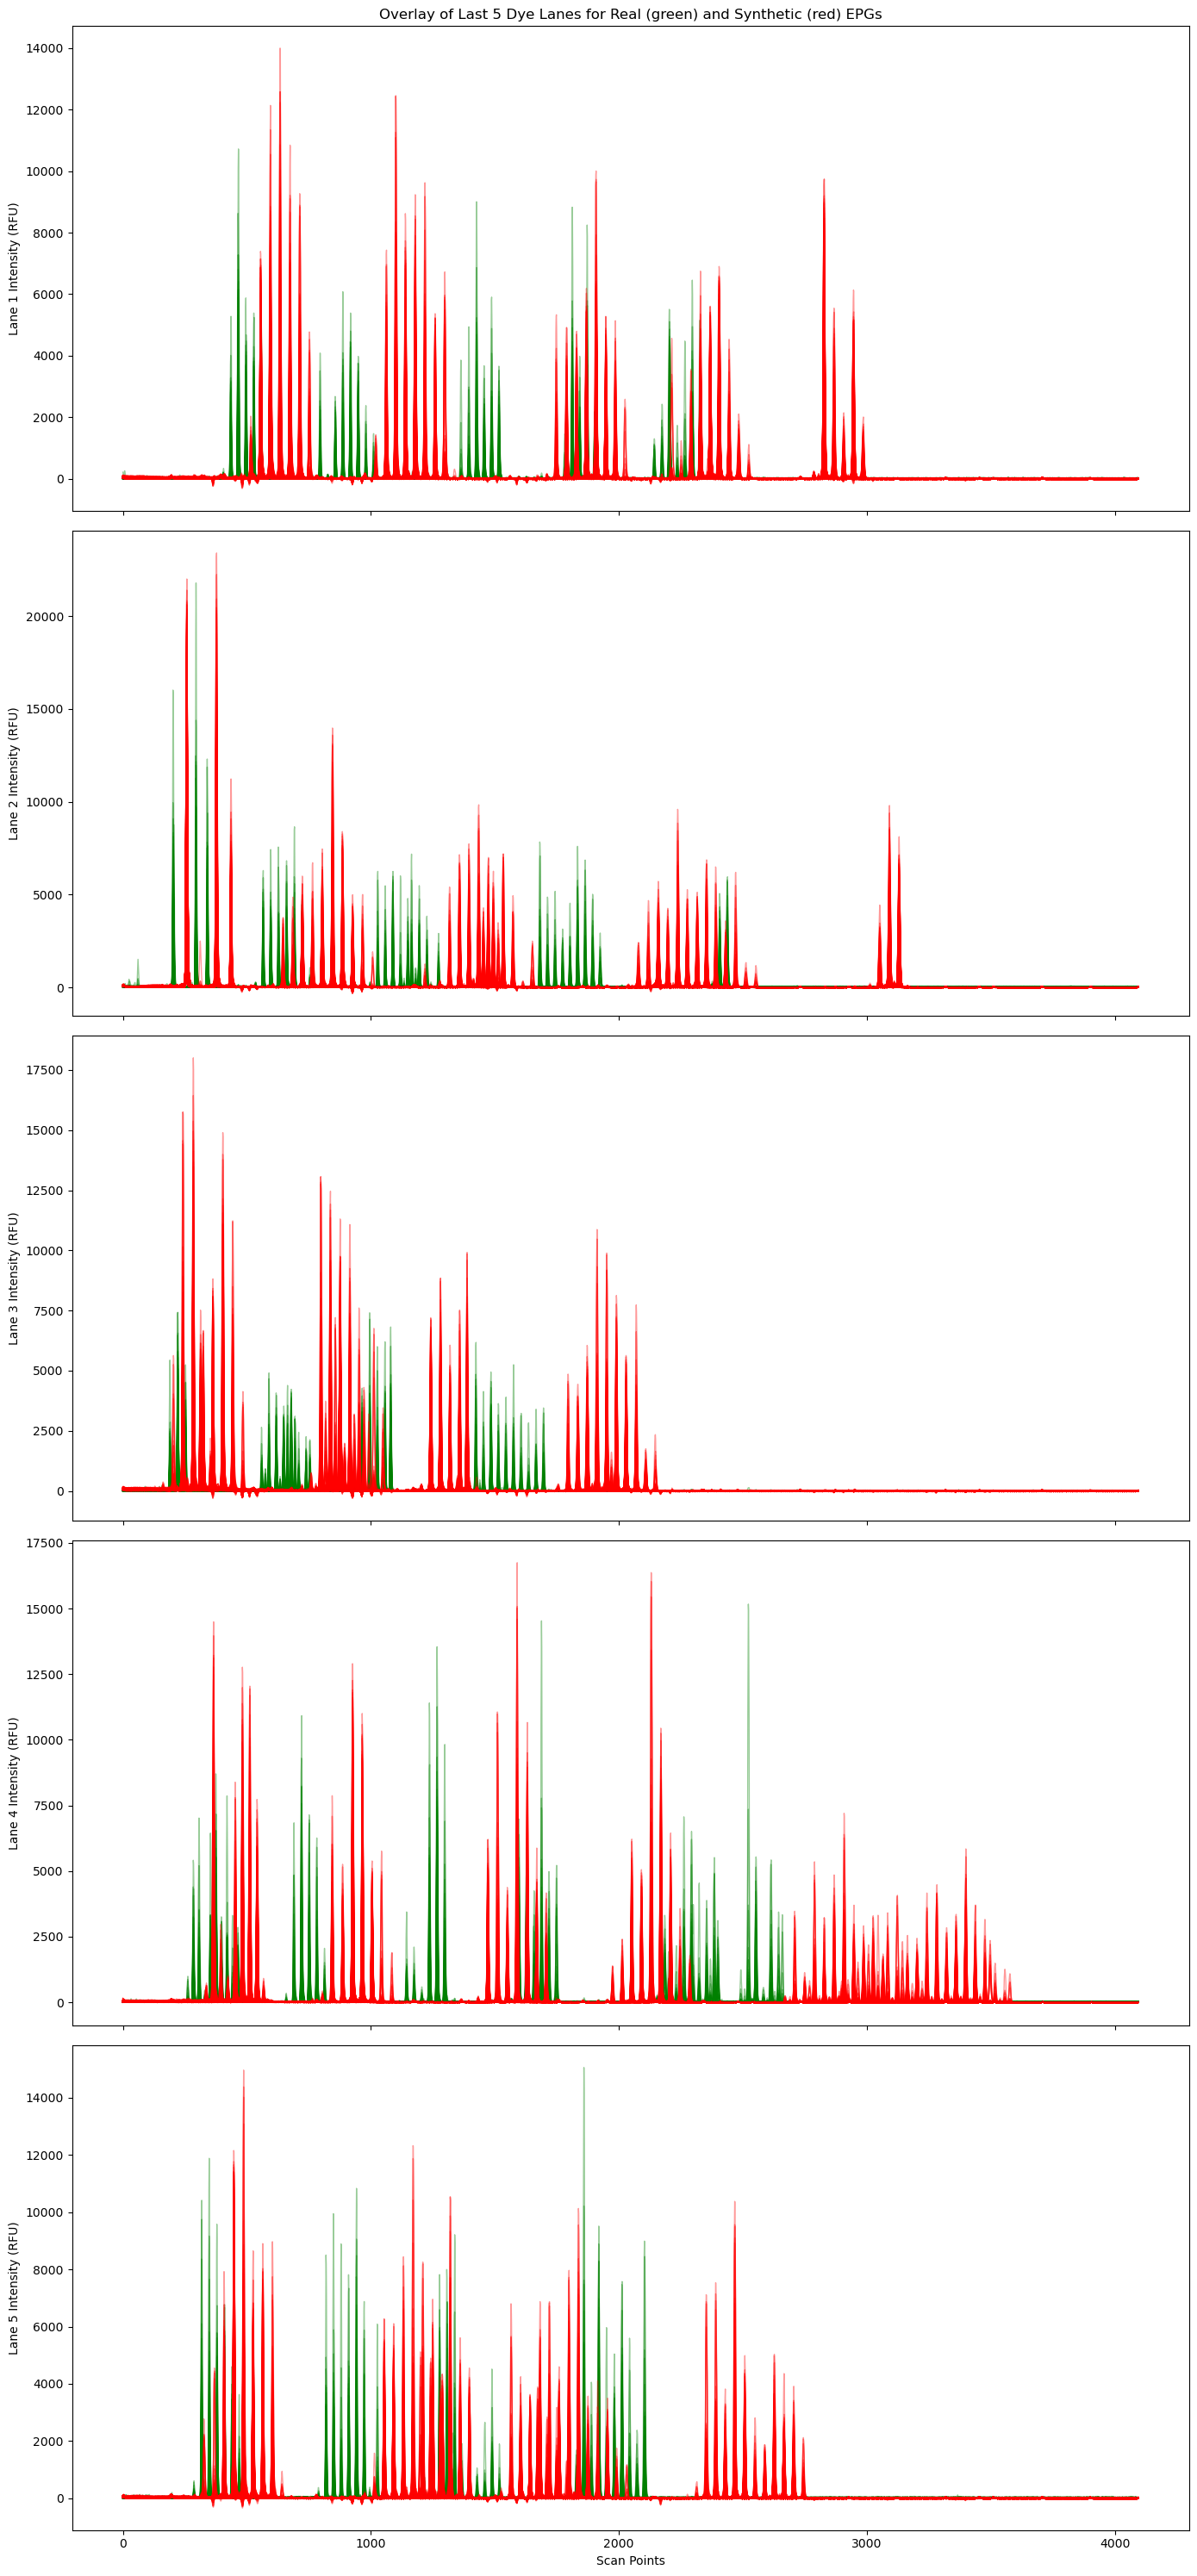

In [8]:
ratio = 2
for f, fold in enumerate(genotype_folds[4:]):
    print(f"Starting fold {fold}")
    for seed in range(1):
        print(f"  Starting seed {seed}")

        meta = {
            "experiment": "Synth_data-Genotype_aware-SPS",
            "model": "Amar-DNANet_Advanced",
            "dataset": f"proved_it_+_synth_1:{ratio}",
            "fold": f,
            "seed": seed,
        }

        run_cross(
            real_data_config="provedit_data.yaml",
            synth_data_config="synth_data.yaml",
            model_config="unet_amar.yaml",
            training_config="synth_training_amar.yaml",
            meta=meta,
            # checkpoint_dir="resources/model/current_best_unet/",
        )